# Multimodal LLMs Hands-on: Gemma 4 on Google Colab T4

In this notebook we will use **Gemma 4 E2B IT** to demonstrate multimodal LLM behavior.

We will cover:

1. What multimodality means for LLMs.
2. How to read Gemma model names.
3. What “effective parameters” and “active parameters” mean.
4. Why model size is not the same as runtime memory.
5. How to run image + text prompts.
6. How to test captioning, visual question answering, OCR-like reading, chart understanding, and hallucination control.
7. How to reason about whether a model fits into a Colab T4 GPU.

Gemma 4 models are multimodal models from Google DeepMind. They handle text and image input, and the smaller E2B/E4B variants also support audio input. They generate text output.

Source: Google Gemma 4 model card. Gemma 4 models support text and image input, with audio support on E2B and E4B. The family includes E2B, E4B, 26B A4B, and 31B variants.

Google lists Gemma 4 as multimodal with text/image input, audio on the small models, and four sizes: E2B, E4B, 26B A4B, and 31B.

## 1. How to read Gemma 4 model names

Example model name:

`google/gemma-4-E2B-it`

Let us split it:

- `google`  
  The Hugging Face organization.

- `gemma-4`  
  The model family and generation.

- `E2B`  
  “Effective 2B”. This does **not** mean the model has exactly 2 billion stored parameters.  
  For Gemma 4 E2B, Google reports **2.3B effective parameters** and **5.1B parameters including embeddings**.

- `it`  
  Instruction-tuned. This version is optimized for following user instructions and chat-style prompts.

Other examples:

- `google/gemma-4-E4B-it`  
  Instruction-tuned Effective 4B model.

- `google/gemma-4-26B-A4B-it`  
  26B Mixture-of-Experts model with about 4B active parameters.

- `google/gemma-4-31B-it`  
  Dense 31B model.

Google’s model card states that E2B has 2.3B effective parameters / 5.1B with embeddings, E4B has 4.5B effective / 8B with embeddings, and 26B A4B has 25.2B total / 3.8B active parameters.

## 2. Effective parameters vs total parameters vs active parameters

There are three different ideas that students often confuse.

### 2.1 Total parameters

This is the total number of stored model parameters.

For a dense model, almost all model parameters are used during inference.

Example:

`gemma-4-31B-it`

This is a dense model with about 30.7B parameters.

### 2.2 Effective parameters

Gemma 4 E2B and E4B use the letter `E`, meaning **effective parameters**.

For example:

- Gemma 4 E2B: 2.3B effective parameters, 5.1B including embeddings.
- Gemma 4 E4B: 4.5B effective parameters, 8B including embeddings.

The important point:

> Effective parameter count is closer to the “compute-like” size of the model, but memory still has to account for the full stored weights.

So for VRAM planning, do **not** look only at “E2B”.  
You should also look at the total parameter count including embeddings.

### 2.3 Active parameters

In Mixture-of-Experts models, not all parameters are used for every token.

Example:

`gemma-4-26B-A4B-it`

This model has about 25.2B total parameters, but only about 3.8B active parameters per token.

This means:

- compute can be closer to a smaller model,
- but memory must still store or access the full set of expert weights,
- so it does not magically fit into a small GPU.

### Practical rule

For inference memory:

- **Dense model**: stored parameters ≈ active parameters.
- **Effective model**: check both effective and total-with-embeddings.
- **MoE model**: active parameters affect compute; total parameters still strongly affect memory.

## 3. Which Gemma 4 model should we use on Colab T4?

A standard Colab T4 usually has about 16 GB VRAM.

For this notebook we use:

`google/gemma-4-E2B-it`

Why?

- It is the smallest Gemma 4 multimodal instruction-tuned model.
- It supports text + image.
- It also supports audio input.
- It has a 128K context window.
- It is much more realistic for Colab T4 than E4B, 26B A4B, or 31B.

Optional:

`google/gemma-4-E4B-it`

This may work with quantization or careful memory management, but it is risky as a default for students.

Do not use as the main Colab T4 model:

- `google/gemma-4-26B-A4B-it`
- `google/gemma-4-31B-it`

# Setup

In [ ]:
# Colab setup
!pip install -U transformers accelerate torch torchvision torchaudio pillow requests bitsandbytes

In [ ]:
import torch
import gc
import os
from PIL import Image
import requests
from io import BytesIO

print("Torch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
    print("Total VRAM, GB:", round(torch.cuda.get_device_properties(0).total_memory / 1024**3, 2))

Torch version: 2.12.0+cu130
CUDA available: True
GPU: Tesla T4
Total VRAM, GB: 14.56


# Utility: GPU memory monitor

In [ ]:
def show_gpu_memory():
    if not torch.cuda.is_available():
        print("CUDA is not available.")
        return

    allocated = torch.cuda.memory_allocated() / 1024**3
    reserved = torch.cuda.memory_reserved() / 1024**3
    total = torch.cuda.get_device_properties(0).total_memory / 1024**3

    print(f"Allocated VRAM: {allocated:.2f} GB")
    print(f"Reserved VRAM:  {reserved:.2f} GB")
    print(f"Total VRAM:     {total:.2f} GB")


def clean_memory():
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
        torch.cuda.ipc_collect()
    show_gpu_memory()


show_gpu_memory()

Allocated VRAM: 0.00 GB
Reserved VRAM:  0.00 GB
Total VRAM:     14.56 GB


## 4. Hugging Face access

Some Google models may require accepting model terms on Hugging Face.

If loading fails with an authorization error:

1. Open the model page on Hugging Face.
2. Log in.
3. Accept the model terms if required.
4. Create a Hugging Face access token.
5. Run the login cell below.

In [ ]:
from huggingface_hub import notebook_login

# Uncomment if needed:
# notebook_login()

# Load Gemma 4 E2B IT

In [ ]:
from transformers import AutoProcessor, AutoModelForMultimodalLM

MODEL_ID = "google/gemma-4-E2B-it"

processor = AutoProcessor.from_pretrained(MODEL_ID)

model = AutoModelForMultimodalLM.from_pretrained(
    MODEL_ID,
    dtype="auto",
    device_map="auto",
)

model.eval()
show_gpu_memory()

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:122: UserWarning: 
Error while fetching `HF_TOKEN` secret value from your vault: 'Requesting secret HF_TOKEN timed out. Secrets can only be fetched when running from the Colab UI.'.
You are not authenticated with the Hugging Face Hub in this notebook.
If the error persists, please let us know by opening an issue on GitHub (https://github.com/huggingface/huggingface_hub/issues/new).
  warnings.warn(


processor_config.json:   0%|          | 0.00/1.69k [00:00<?, ?B/s]

chat_template.jinja:   0%|          | 0.00/17.3k [00:00<?, ?B/s]

config.json:   0%|          | 0.00/4.95k [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/2.10k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/32.2M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/10.2G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/1951 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/208 [00:00<?, ?B/s]

Allocated VRAM: 9.51 GB
Reserved VRAM:  9.60 GB
Total VRAM:     14.56 GB


In [ ]:
def load_image_from_url(url: str) -> Image.Image:
    response = requests.get(url)
    response.raise_for_status()
    image = Image.open(BytesIO(response.content)).convert("RGB")
    return image


def display_image(image: Image.Image, max_width: int = 500):
    display(image.resize((max_width, int(max_width * image.height / image.width))))

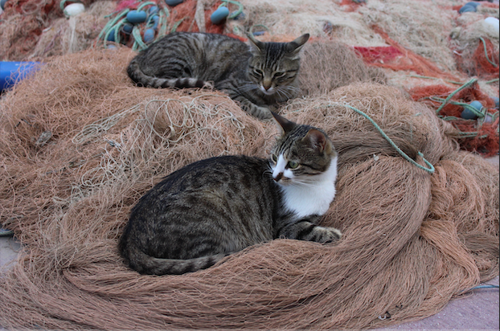

In [ ]:
sample_image_url = "https://huggingface.co/datasets/huggingface/documentation-images/resolve/main/cats.png"

image = load_image_from_url(sample_image_url)
display_image(image)

In [ ]:
# # Optional cell: upload your own image from local machine to Colab

# from google.colab import files
# from PIL import Image

# image_filename = 'my_image.png'

# # Open image and convert to RGB
# user_image = Image.open(image_filename).convert("RGB")

# print("Uploaded file:", image_filename)
# print("Image size:", user_image.size)

# display_image(user_image)

# General multimodal generation helper

In [ ]:
def ask_gemma_about_image(
    image: Image.Image,
    question: str,
    max_new_tokens: int = 256,
    temperature: float = 1.0,
    top_p: float = 0.95,
    top_k: int = 64,
):
    messages = [
        {
            "role": "user",
            "content": [
                {"type": "image", "image": image},
                {"type": "text", "text": question},
            ],
        }
    ]

    inputs = processor.apply_chat_template(
        messages,
        tokenize=True,
        return_dict=True,
        return_tensors="pt",
        add_generation_prompt=True,
    ).to(model.device)

    input_len = inputs["input_ids"].shape[-1]

    with torch.inference_mode():
        outputs = model.generate(
            **inputs,
            max_new_tokens=max_new_tokens,
            do_sample=True,
            temperature=temperature,
            top_p=top_p,
            top_k=top_k,
        )

    generated = outputs[0][input_len:]
    decoded = processor.decode(generated, skip_special_tokens=False)

    try:
        return processor.parse_response(decoded)
    except Exception:
        return decoded

In [ ]:
# user_prompt = """
# Analyze this image.

# Return:
# 1. Main objects:
# 2. Visible text:
# 3. What is happening:
# 4. Important visual details:
# 5. Uncertain or unclear parts:

# Do not invent details that are not visible.
# """

# answer = ask_gemma_about_image(
#     user_image,
#     user_prompt,
#     max_new_tokens=500,
# )

# print(answer)

## 5. Demo 1: Image captioning

The first task is simple captioning.

We ask the model:

> What is shown in this image?

This tests whether the model can identify the main visual content.

In [ ]:
answer = ask_gemma_about_image(
    image,
    "What is shown in this image? Answer in 3-5 sentences."
)

print(answer)

{'role': 'assistant', 'content': 'This image features a tabby cat resting on a large pile of brown, fibrous material, likely hay or straw. The cat has distinct brown and grey markings on its fur and appears to be relaxing in the soft bedding. The surrounding material is abundant, creating a textured and cozy environment for the animal. Overall, the picture depicts a domestic cat in a natural or rustic setting.'}


## 6. Demo 2: Visual Question Answering

Visual Question Answering means that the model receives an image and a question about the image.

Examples:

- What objects are visible?
- What is the dominant color?
- Is there text in the image?
- What is likely happening?

In [ ]:
questions = [
    "What are the main objects in the image?",
    "Is this image more likely taken indoors or outdoors?",
    "What visual evidence supports your answer?",
]

for q in questions:
    print("=" * 80)
    print("QUESTION:", q)
    print()
    print(ask_gemma_about_image(image, q, max_new_tokens=180))

QUESTION: What are the main objects in the image?

{'role': 'assistant', 'content': 'The main objects in the image are:\n\n1. **Cats:** There are at least two cats visible, lying on top of or within the hay.\n2. **Hay/Straw:** A large amount of dry, brown, fibrous material (likely hay or straw) that the cats are resting on.\n3. **Background Material:** There appears to be some other material in the background, including some colorful strands (perhaps dyed fibers or yarn) and some small, smooth objects (possibly stones or beads) near the top.'}
QUESTION: Is this image more likely taken indoors or outdoors?

{'role': 'assistant', 'content': "Based on the appearance of the materials and the overall setting, this image is **more likely taken outdoors**.\n\nHere's why:\n\n1. **Hay/Straw:** The cat is resting on a large pile of what appears to be dried hay or straw. This kind of bedding is commonly used outdoors for animals or in outdoor/rustic settings.\n2. **Background Texture:** The backg

## 7. Demo 3: Structured image analysis

Instead of asking for a generic description, we can ask for a structured output.

This is useful because multimodal models may otherwise produce fluent but vague answers.

In [ ]:
structured_prompt = """
Analyze the image using this structure:

1. Main subject:
2. Background:
3. Visible objects:
4. Visible text:
5. Spatial relations:
6. Uncertain details:

Important:
- Do not guess hidden details.
- If something is not visible, say "not visible".
"""

print(ask_gemma_about_image(image, structured_prompt, max_new_tokens=400))

{'role': 'assistant', 'content': 'Here is an analysis of the image based on the requested structure:\n\n1. **Main subject:** A tabby cat is prominently featured, lying down on a pile of brown, fibrous material.\n2. **Background:** The background consists primarily of more piles of the same brown, fibrous material, and some hints of other colors (like red/orange/brown) and possibly some scattered objects on top.\n3. **Visible objects:**\n    * Two cats (tabby cats)\n    * A large pile of brown, fibrous material (resembling hay, rope, or thick twine)\n    * Some small, round, colored objects (blue, green, dark) visible in the upper background/top edge.\n4. **Visible text:** There is no discernible visible text in the image.\n5. **Spatial relations:**\n    * The main cat is lying on top of the central pile of brown material.\n    * Another cat is positioned slightly behind and above the first cat, also resting on the pile.\n    * The fibrous material dominates the foreground and middle gr

## 8. Demo 4: Hallucination control

Multimodal models can hallucinate.  
They may describe objects that are not actually visible.

A safer prompt explicitly says:

- answer only from visible evidence,
- separate facts from guesses,
- say when something is not visible.

In [ ]:
unsafe_prompt = "Tell me everything about this place, including its history and who built it."

safe_prompt = """
Answer only based on the visible image.

Use this format:

Visible evidence:
- ...

Not visible / cannot determine:
- ...

Possible but uncertain:
- ...

Do not provide historical facts unless they are directly visible in the image.
"""

print("UNSAFE PROMPT OUTPUT")
print("=" * 80)
print(ask_gemma_about_image(image, unsafe_prompt, max_new_tokens=300))

print("\n\nSAFE PROMPT OUTPUT")
print("=" * 80)
print(ask_gemma_about_image(image, safe_prompt, max_new_tokens=300))

UNSAFE PROMPT OUTPUT
{'role': 'assistant', 'content': 'Based **only** on the image provided, I can tell you the following:\n\n**What I can observe:**\n\n* **Subject:** The central focus of the image is a domestic cat lying down amidst a large pile of thick, brown, fibrous material.\n* **Material:** The material appears to be some kind of natural fiber, possibly jute, sisal, or some type of coarse, dried plant matter, used to create a large, textured nest or bedding.\n* **Setting/Context:** The cat is resting comfortably on this material. There are hints of other colors and textures (some reddish/orange tones in the background), suggesting this might be an outdoor, rustic, or perhaps a specialized animal habitat.\n* **Atmosphere:** The image has a rustic, natural, and perhaps somewhat informal feel.\n\n**What I *cannot* tell you:**\n\n**I have absolutely no information about the history, location, builders, purpose, or specific context of this place.**\n\nThe image is a photograph of a 

## 9. Demo 5: OCR-like reading

Gemma 4 can be used for OCR-like tasks.

Important distinction:

- Dedicated OCR systems are usually better for exact text extraction.
- Multimodal LLMs are useful when we need both reading and interpretation.
- For small text, higher visual token budget may be needed.

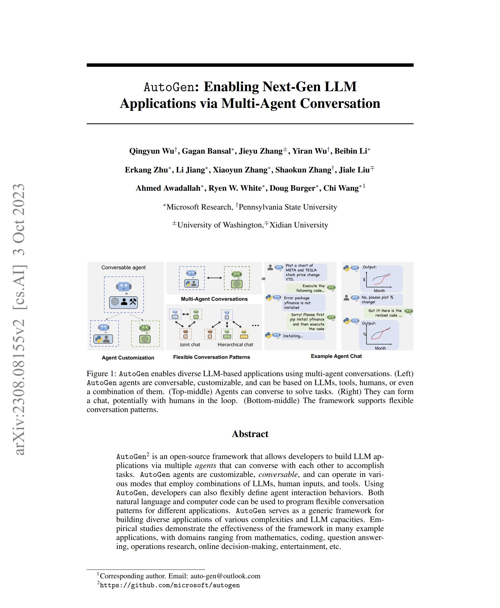

In [ ]:
receipt_url = "https://raw.githubusercontent.com/microsoft/markitdown/main/packages/markitdown/tests/test_files/test.jpg"

receipt_image = load_image_from_url(receipt_url)
display_image(receipt_image)

In [ ]:
ocr_prompt = """
Read the visible text in this image.

Return:

1. Raw visible text:
2. Key fields:
3. Any uncertain or unreadable parts:

Do not invent missing text.
"""

print(ask_gemma_about_image(receipt_image, ocr_prompt, max_new_tokens=500))

{'role': 'assistant', 'content': '1. Raw visible text:\nAutoGen: Enabling Next-Gen LLM Applications via Multi-Agent Conversation\n\nQingyun Wu$^1$, Gagan Bansal$^2$, Jieyu Zhang$^2$, Yiran Wu$^1$, Beibin Li$^1$\nErkang Zhu$^1$, Li Jiang$^1$, Xiaoyun Zhang$^1$, Shaokun Zhang$^1$, Jiale Liu$^1$\n\nAhmed Awadallah$^4$, Ryen W. White$^5$, Doug Burger$^5$, Chi Wang$^1$\n\n$^1$Microsoft Research, $^2$Pennsylvania State University\n$^4$University of Washington, $^5$Xidian University\n\nFigure 1: AutoGen enables diverse LLM-based applications using multi-agent conversations. (Left)\nAutoGen agents are conservative, customizable, and can be based on LLMs, tools, humans, or even\na combination of them. (Top-middle) Agents can converse to solve tasks. (Right) They can form\na chat, potentially with humans in the loop. (Bottom-middle) The framework supports flexible\nconversation patterns.\n\nAbstract\nAutoGen$^2$ is an open-source framework that allows developers to build LLM ap-\nplications via 

## 10. Demo 6: Chart understanding

A useful multimodal use case is chart interpretation.

The model should not only describe pixels.  
It should infer the chart message:

- What is plotted?
- What trend is visible?
- What is the likely conclusion?
- What should not be overclaimed?

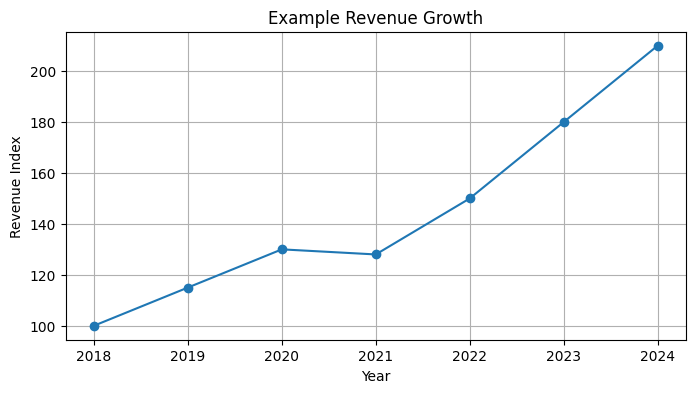

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

x = np.arange(2018, 2025)
y = np.array([100, 115, 130, 128, 150, 180, 210])

plt.figure(figsize=(8, 4))
plt.plot(x, y, marker="o")
plt.title("Example Revenue Growth")
plt.xlabel("Year")
plt.ylabel("Revenue Index")
plt.grid(True)
plt.savefig("chart.png", dpi=160, bbox_inches="tight")
plt.show()

In [ ]:
chart_image = Image.open("chart.png").convert("RGB")

chart_prompt = """
Analyze this chart.

Return:

1. What variables are shown?
2. What is the main trend?
3. Are there any dips or anomalies?
4. What would be a cautious business interpretation?
5. What should we NOT conclude from this chart alone?
"""

print(ask_gemma_about_image(chart_image, chart_prompt, max_new_tokens=500))

{'role': 'assistant', 'content': 'Here is an analysis of the provided chart titled "Example Revenue Growth":\n\n---\n\n### Analysis of the Chart\n\n**1. What variables are shown?**\n*   **X-axis (Independent Variable):** Year (ranging from 2018 to 2024).\n*   **Y-axis (Dependent Variable):** Revenue Index (ranging from 100 to over 200).\n\n**2. What is the main trend?**\nThe main trend shown in the data is a **strong, consistent upward growth** in the Revenue Index over the period from 2018 to 2024. Revenue is generally increasing year over year.\n\n**3. Are there any dips or anomalies?**\nYes, there is a slight dip or plateau in growth:\n*   Revenue appears to increase from 2018 to 2020.\n*   There is a slight **decrease or stagnation** between 2020 and 2021 (the point for 2021 is lower than 2020).\n*   Following 2021, the growth resumes a steep and accelerating upward trend through 2024.\n\n**4. What would be a cautious business interpretation?**\nA cautious interpretation suggests t

## 11. Demo 7: Prompt sensitivity

The same image can produce different answers depending on the prompt.

We compare:

1. vague prompt,
2. detailed prompt,
3. evidence-constrained prompt.

In [ ]:
prompts = {
    "Vague": "Describe this image.",
    "Detailed": """
Describe this image in detail.
Mention objects, colors, spatial layout, background, and possible context.
""",
    "Evidence-constrained": """
Describe only what is directly visible.
Separate observations from guesses.
Use:
- Observations:
- Uncertain:
- Not visible:
""",
}

for name, prompt in prompts.items():
    print("=" * 80)
    print(name.upper())
    print("=" * 80)
    print(ask_gemma_about_image(image, prompt, max_new_tokens=350))
    print()

VAGUE
{'role': 'assistant', 'content': "This is an image of a tabby cat resting on a large pile of brown, fibrous material, likely hay or straw.\n\nHere's a more detailed description:\n\n*   **Subject:** The main subject is a domestic cat with tabby markings (grey/brown stripes). It appears to be lying down comfortably on the pile.\n*   **Setting/Surface:** The cat is situated on a very large, voluminous heap of light brown, tangled, fibrous material, which fills most of the foreground and middle ground. This material looks soft and somewhat messy.\n*   **Other Elements:** In the background and around the edges of the pile, there are hints of other materials, including some reddish or orange tones, and what look like small, colorful objects (possibly beads or stones) mixed in with the fibrous material. There are also some green strings or twine visible.\n*   **Mood/Impression:** The image conveys a sense of relaxation and comfort, as the cat is settled in the soft bedding.\n\nOverall, 

## 12. Demo 8: Upload your own image

Now students can upload their own image and ask questions about it.

In [ ]:
# from google.colab import files

# uploaded = files.upload()

# uploaded_path = next(iter(uploaded.keys()))
# student_image = Image.open(uploaded_path).convert("RGB")

# display_image(student_image)

In [ ]:
# student_question = """
# Analyze this image.

# Return:

# 1. Main objects:
# 2. Visible text:
# 3. What is happening:
# 4. Anything uncertain:
# 5. One useful follow-up question a user could ask:
# """

# print(ask_gemma_about_image(student_image, student_question, max_new_tokens=500))

## 13. Optional: Audio input

Gemma 4 E2B and E4B support audio input.

This is important because multimodality is not only image + text.

A multimodal model may process:

- text,
- images,
- audio,
- video as frames.

For this lecture, image input is the main focus because it is easier to demonstrate reliably in Colab. Audio can be shown as an optional extension.

## 14. Why parameter count is not equal to VRAM usage

A simple approximation:

```text
weight memory ≈ number_of_parameters × bytes_per_parameter
```
Common formats:

* FP32: 4 bytes per parameter
* FP16/BF16: 2 bytes per parameter
* INT8: 1 byte per parameter
* 4-bit: 0.5 bytes per parameter

But real inference memory is larger because we also need:

* KV cache,
* activations,
* temporary CUDA buffers,
* tokenizer and processor objects,
* vision/audio encoder memory,
* loaded images,
* framework overhead.

For multimodal models, images are converted into visual tokens.
More image tokens means more memory and compute.

In [ ]:
def estimate_weight_memory_billions(params_b: float, bytes_per_param: float):
    gb = params_b * 1e9 * bytes_per_param / 1024**3
    return gb


models = {
    "Gemma 4 E2B effective": 2.3,
    "Gemma 4 E2B incl. embeddings": 5.1,
    "Gemma 4 E4B effective": 4.5,
    "Gemma 4 E4B incl. embeddings": 8.0,
    "Gemma 4 26B A4B total": 25.2,
    "Gemma 4 26B A4B active": 3.8,
    "Gemma 4 31B dense": 30.7,
}

for name, params_b in models.items():
    fp16_gb = estimate_weight_memory_billions(params_b, 2)
    int8_gb = estimate_weight_memory_billions(params_b, 1)
    int4_gb = estimate_weight_memory_billions(params_b, 0.5)

    print(f"{name:35s} | FP16: {fp16_gb:6.2f} GB | INT8: {int8_gb:6.2f} GB | 4-bit: {int4_gb:6.2f} GB")

Gemma 4 E2B effective               | FP16:   4.28 GB | INT8:   2.14 GB | 4-bit:   1.07 GB
Gemma 4 E2B incl. embeddings        | FP16:   9.50 GB | INT8:   4.75 GB | 4-bit:   2.37 GB
Gemma 4 E4B effective               | FP16:   8.38 GB | INT8:   4.19 GB | 4-bit:   2.10 GB
Gemma 4 E4B incl. embeddings        | FP16:  14.90 GB | INT8:   7.45 GB | 4-bit:   3.73 GB
Gemma 4 26B A4B total               | FP16:  46.94 GB | INT8:  23.47 GB | 4-bit:  11.73 GB
Gemma 4 26B A4B active              | FP16:   7.08 GB | INT8:   3.54 GB | 4-bit:   1.77 GB
Gemma 4 31B dense                   | FP16:  57.18 GB | INT8:  28.59 GB | 4-bit:  14.30 GB


## 15. Important note: MoE active parameters are not enough for VRAM planning

For `gemma-4-26B-A4B-it`, the name means:

- `26B`: total parameter class,
- `A4B`: roughly 4B active parameters per token,
- `MoE`: Mixture-of-Experts architecture.

This can make inference compute faster than a dense 26B model.

However:

> Active parameters are not the same as stored parameters.

The model still contains many more total parameters than the active subset.  
So for Colab T4, `26B-A4B` is not equivalent to loading a normal 4B model.

Student rule:

- Use **active parameters** to reason about per-token compute.
- Use **total parameters** to reason about model storage and memory pressure.
- Use actual runtime tests to confirm whether the model fits.

## 16. Visual token budget

Gemma 4 supports configurable visual token budgets.

This controls how many tokens represent the image.

Lower visual token budget:

- faster,
- less memory,
- good for simple captioning or classification.

Higher visual token budget:

- slower,
- more memory,
- better for OCR, small text, documents, tables, charts.

Practical rule:

- Use low budget for “what is in the image?”
- Use high budget for “read this document / receipt / chart”.

In [ ]:
SAFE_VISUAL_PROMPT_TEMPLATE = """
You are analyzing an image.

Task:
{task}

Rules:
1. Use only visible evidence.
2. Do not invent hidden details.
3. If something is unclear, say "unclear".
4. Separate observations from interpretation.
5. Do not identify real people.
6. Do not infer sensitive attributes.

Return:

Observations:
- ...

Interpretation:
- ...

Uncertain:
- ...
"""

In [ ]:
# task = "Describe the image and explain what the user should notice."
# prompt = SAFE_VISUAL_PROMPT_TEMPLATE.format(task=task)

# print(ask_gemma_about_image(student_image, prompt, max_new_tokens=500))

## 17. Mini benchmark

Now we create a tiny manual evaluation set.

For each image, ask:

1. captioning question,
2. counting question,
3. OCR-like question,
4. hallucination-control question.

Students should compare:

- correctness,
- uncertainty handling,
- visible evidence,
- hallucinations,
- usefulness of structure.

In [ ]:
benchmark_items = [
    {
        "name": "Test sample",
        "image": image,
        "questions": [
            "Describe the image in one sentence.",
            "What large structure is visible?",
            "Is there readable text? If yes, transcribe it.",
            "What cannot be determined from this image alone?",
        ],
    },
    {
        "name": "Chart sample",
        "image": chart_image,
        "questions": [
            "What type of chart is this?",
            "What is the main trend?",
            "What is the approximate value in the last year?",
            "What should we not conclude from this chart alone?",
        ],
    },
]

for item in benchmark_items:
    print("=" * 100)
    print("IMAGE:", item["name"])
    print("=" * 100)

    for q in item["questions"]:
        print("\nQUESTION:", q)
        print("-" * 80)
        print(ask_gemma_about_image(item["image"], q, max_new_tokens=220))

IMAGE: Test sample

QUESTION: Describe the image in one sentence.
--------------------------------------------------------------------------------
{'role': 'assistant', 'content': 'A tabby cat is relaxing on a large pile of brown, fibrous material.'}

QUESTION: What large structure is visible?
--------------------------------------------------------------------------------
{'role': 'assistant', 'content': 'Based on the image, the most prominent feature is a large pile of **hay or straw**.\n\nThis material is what the cat is lying on and interacting with, suggesting it is a large **hay bale** or a similar agricultural/animal bedding material.'}

QUESTION: Is there readable text? If yes, transcribe it.
--------------------------------------------------------------------------------
{'role': 'assistant', 'content': 'I do not see any readable text in the image. The image primarily features a cat lying on a large pile of brown, fibrous material (possibly hay or straw).'}

QUESTION: What can

# Final takeaways

1. Multimodal LLMs process more than text.
2. Gemma 4 can process image + text prompts and generate text answers.
3. E2B/E4B also support audio.
4. Model names matter:
   - `E` = effective parameters,
   - `A` = active parameters,
   - `it` = instruction-tuned.
5. Active parameters help estimate compute, not full memory.
6. Total parameters and precision are critical for VRAM planning.
7. On Colab T4, `gemma-4-E2B-it` is the safest default.
8. Prompting matters a lot for image understanding.
9. Good multimodal prompts separate observations, interpretation, and uncertainty.
10. For OCR and charts, ask the model to avoid guessing.